# Q1: Does Every ADL Correspond to a Liquidation?

This notebook independently reads cleaned data and studies the relationship among ADL fills, liquidation fills, and ledger liquidation events. Figures and tables are written under `notebook_outputs/q1_adl_vs_liquidation/`.

## Research Questions

1. Can every ADL be matched to one or more liquidation events in a nearby time window?
2. Can one liquidation correspond to multiple ADL fills?
3. Can one ADL aggregate span multiple accounts, coins, or fills?
4. Are ADL trigger times continuous, or do they appear in bursts or clusters?
5. Is ADL concentrated in specific coins, time windows, or market states?
6. How do ADL and ordinary liquidation align across time, coin, side, size, and price?

## Core Hypotheses

- H1: An ADL fill usually matches a liquidation fill on the same trade key or in a very tight time window.
- H2: A single liquidation trade/event can split into multiple ADL fills.
- H3: ADL is not uniformly distributed over time; it clusters in bursts.
- H4: ADL concentrates in a small set of coins and high-impact market states such as wide spread, low depth, or high liquidation activity.

In [8]:
QUESTION_ID = 'q1_adl_vs_liquidation'

from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', lambda x: f'{x:,.6g}')
for _style in ['seaborn-v0_8-whitegrid', 'seaborn-whitegrid', 'ggplot']:
    try:
        plt.style.use(_style)
        break
    except OSError:
        pass

PROJECT_SLUG = 'hyperliquid-liquidation-cascade-2025-10'
DATASET_ID = 'hyperliquid_20251010_21'

def find_project_dir(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        candidates = [path]
        if path.name != PROJECT_SLUG:
            candidates.append(path / 'projects' / PROJECT_SLUG)
        for candidate in candidates:
            if (candidate / 'reproducibility/dataset_config.yaml').exists():
                return candidate
    raise RuntimeError('Cannot find project directory')

PROJECT_DIR = find_project_dir()
REPO_ROOT = PROJECT_DIR.parents[1] if PROJECT_DIR.parent.name == 'projects' else PROJECT_DIR.parent
PROJECT_ROOT = REPO_ROOT
CLEANED = REPO_ROOT / 'data/hyperliquid/cleaned' / DATASET_ID
NOTEBOOK_DIR = PROJECT_DIR / 'notebooks'
OUTPUT_DIR = PROJECT_DIR / 'notebook_outputs' / QUESTION_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def display_path(path, base=REPO_ROOT):
    path = Path(path).resolve()
    try:
        return path.relative_to(Path(base).resolve())
    except ValueError:
        return Path(path.name)

print('PROJECT_DIR =', display_path(PROJECT_DIR))
print('CLEANED =', display_path(CLEANED))
print('OUTPUT_DIR =', display_path(OUTPUT_DIR))

def parquet_parts(path):
    path = Path(path)
    if path.is_dir():
        return sorted(path.glob('part-*.parquet'))
    return [path]

def read_parquet(path, columns=None, max_parts=None):
    parts = parquet_parts(path)
    if max_parts is not None:
        parts = parts[:max_parts]
    if len(parts) == 1:
        return pd.read_parquet(parts[0], columns=columns)
    return pd.read_parquet([str(p) for p in parts], columns=columns)

def parquet_rows(path):
    return sum(pq.ParquetFile(p).metadata.num_rows for p in parquet_parts(path))

def to_num(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

def to_utc(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], utc=True)
    return df

def lower_addr(s):
    return s.astype('string').str.lower()

def write_table(df, name, index=False):
    path = OUTPUT_DIR / name
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=index)
    display(df.head(25))
    print('wrote', path.relative_to(PROJECT_ROOT))
    return df

def save_fig(fig, name):
    path = OUTPUT_DIR / name
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=160, bbox_inches='tight')
    print('wrote', path.relative_to(PROJECT_ROOT))
    return path

def plot_ts(df, cols, title, ylabel='', name=None, figsize=(13,4)):
    fig, ax = plt.subplots(figsize=figsize)
    df[cols].plot(ax=ax, linewidth=1.5)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=.25)
    if name:
        save_fig(fig, name)
    plt.show()
    return fig

def log_heatmap(pivot, title, name=None, figsize=(14,6)):
    values = np.log1p(pivot.astype(float).replace([np.inf, -np.inf], np.nan).fillna(0).T)
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(values, aspect='auto', interpolation='nearest', cmap='viridis')
    ax.set_title(title)
    ax.set_yticks(range(len(values.index)))
    ax.set_yticklabels(values.index)
    if len(values.columns):
        step = max(1, len(values.columns)//8)
        ax.set_xticks(range(0, len(values.columns), step))
        ax.set_xticklabels([str(x) for x in values.columns[::step]], rotation=30, ha='right')
    fig.colorbar(im, ax=ax, label='log1p(value)')
    plt.tight_layout()
    if name:
        save_fig(fig, name)
    plt.show()
    return fig

def evidence(rows):
    df = pd.DataFrame(rows)
    write_table(df, 'evidence_assessment.csv')
    return df

def nearest_match(left, right, by, left_on='time', right_on='time', tolerance=0, suffix='_match'):
    frames = []
    for key, lgrp in left.groupby(by, dropna=False):
        rgrp = right[right[by].eq(key)]
        if rgrp.empty or lgrp.empty:
            tmp = lgrp.copy()
            tmp['_matched'] = False
            frames.append(tmp)
            continue
        lgrp = lgrp.sort_values(left_on)
        rgrp = rgrp.sort_values(right_on)
        merged = pd.merge_asof(
            lgrp,
            rgrp,
            left_on=left_on,
            right_on=right_on,
            direction='nearest',
            tolerance=tolerance,
            suffixes=('', suffix),
        )
        merged['_matched'] = merged[f'{right_on}{suffix}'].notna() if f'{right_on}{suffix}' in merged.columns else merged[right_on].notna()
        frames.append(merged)
    return pd.concat(frames, ignore_index=True) if frames else left.assign(_matched=False)

PROJECT_ROOT = <project-root>
CLEANED = <project-root>/data/hyperliquid/cleaned/hyperliquid_20251010_21
OUTPUT_DIR = <project-root>/notebooks/hyperliquid_20251010_21/question_outputs/q1_adl_vs_liquidation


## Data Sources and Field Notes

- `node_fills_by_block/parquet/fills`: fill-level data with `dir`, `liquidationMethod`, `coin`, `px`, `sz`, `time`, `hash`, `oid`, `tid`, and `user`.
- `node_fills_by_block/parquet/adl_events`: ADL paired table built during cleaning, including fields from the ADL row and paired liquidated row.
- `misc_events_by_block/liquidation_events.parquet`: ledger liquidation events with `accountValue` and `liquidatedNtlPos`.
- `l2_book/l2_minute_summary.parquet`: minute/coin market state with spread, depth, and imbalance.
- `asset_ctxs/asset_ctxs_hour.csv`: minute-level asset context with funding, open interest, and mark/oracle basis.

## Event Definitions and Matching Rules

- ADL fill: a fill where `dir == Auto-Deleveraging`; the main analysis uses `adl_events`, with one row per paired ADL event.
- Liquidation fill: a fill row whose `dir` starts with `Liquidated`.
- Forced-liquidation metadata fill: a fill row with non-null `liquidationMethod`.
- Exact trade-key match: exact match on `coin, time, px, sz, hash, oid, tid`.
- Window match: same coin, nearest liquidation fill within `+/-0ms`, `+/-1ms`, or `+/-5ms`.
- Aggregate event key: `blockNumber, time, hash, oid, tid`, used to test whether one on-chain/matching-engine event splits into multiple ADL fills.

In [9]:
NODE = CLEANED / 'node_fills_by_block'
FILLS = NODE / 'parquet/fills'
ADL_PATH = NODE / 'parquet/adl_events'
MISC = CLEANED / 'misc_events_by_block'
L2_MIN = CLEANED / 'l2_book/l2_minute_summary.parquet'
ASSET_HOUR = CLEANED / 'asset_ctxs/asset_ctxs_hour.csv'

fill_cols = ['coin','px','sz','side','time','dir','closedPnl','hash','oid','tid','blockNumber','fillIndex','user','liquidationLiquidatedUser','liquidationMethod','notional','time_utc','minute_utc']
fills = read_parquet(FILLS, columns=fill_cols)
adl = read_parquet(ADL_PATH)
ledger_liq = pd.read_parquet(MISC / 'liquidation_events.parquet')
l2_min = pd.read_parquet(L2_MIN)
asset_hour = pd.read_csv(ASSET_HOUR)

to_num(fills, ['px','sz','closedPnl','notional','time','oid','tid','blockNumber','fillIndex'])
to_utc(fills, ['time_utc','minute_utc'])
to_num(adl, ['px','sz','notional','time','blockNumber','adlFillIndex','liquidatedFillIndex','liquidationMarkPx','liquidationMarkDistanceBps'])
to_utc(adl, ['time_utc','minute_utc'])
to_num(ledger_liq, ['accountValue','liquidatedNtlPos','block_number'])
to_utc(ledger_liq, ['event_time'])
l2_min['minute_utc'] = pd.to_datetime(l2_min['minute_utc'], utc=True)
asset_hour['time_utc'] = pd.to_datetime(asset_hour['time_utc'], utc=True)
asset_hour['minute_utc'] = asset_hour['time_utc'].dt.floor('min')

adl = adl.reset_index(drop=True).reset_index(names='adl_id')
adl_fills = fills[fills['dir'].astype(str).eq('Auto-Deleveraging')].copy().reset_index(drop=True)
liquidated_fills = fills[fills['dir'].astype(str).str.startswith('Liquidated', na=False)].copy().reset_index(drop=True)
forced_liq_meta_fills = fills[fills['liquidationMethod'].notna()].copy().reset_index(drop=True)

summary = pd.DataFrame([
    {'metric':'adl_events_cleaned_rows','value':len(adl)},
    {'metric':'adl_fill_rows_from_fills','value':len(adl_fills)},
    {'metric':'liquidated_dir_fill_rows','value':len(liquidated_fills)},
    {'metric':'forced_liquidation_metadata_rows','value':len(forced_liq_meta_fills)},
    {'metric':'ledger_liquidation_events','value':len(ledger_liq)},
    {'metric':'ledger_liquidation_users','value':ledger_liq['primary_user'].nunique()},
])
write_table(summary, 'q1_event_inventory.csv')

,metric,value
0,adl_events_cleaned_rows,35022
1,adl_fill_rows_from_fills,35022
2,liquidated_dir_fill_rows,70004
3,forced_liquidation_metadata_rows,571840
4,ledger_liquidation_events,14521
5,ledger_liquidation_users,12445


wrote notebooks/hyperliquid_20251010_21/question_outputs/q1_adl_vs_liquidation/q1_event_inventory.csv


,metric,value
0,adl_events_cleaned_rows,35022
1,adl_fill_rows_from_fills,35022
2,liquidated_dir_fill_rows,70004
3,forced_liquidation_metadata_rows,571840
4,ledger_liquidation_events,14521
5,ledger_liquidation_users,12445


## Data Cleaning Logic

Normalize numeric fields, UTC timestamps, and ADL ids. Keep fill-level ADL, liquidated fills, and metadata liquidation fills separate to avoid merging different event semantics.

## Core Statistics: ADL and Liquidation Match Rates

In [16]:
liquidated_fills.head()

,coin,px,sz,side,time,dir,closedPnl,hash,oid,tid,blockNumber,fillIndex,user,liquidationLiquidatedUser,liquidationMethod,notional,time_utc,minute_utc
0,FARTCOIN,0.4799,"418,465",B,1760130002493,Liquidated Isolated Long,0,0x549f603a86d7d3cf5619042d3a377f011200782021da...,194001024170,391018266797124,758790015,0,0x2e3d94f0562703b25c83308a05046ddaf9a8dd14,0x1ed939ef096bab6d68657ea9c1fdf534ead267d6,backstop,"200,821",2025-10-10 21:00:02.493000+00:00,2025-10-10 21:00:00+00:00
1,FARTCOIN,0.4799,"418,465",A,1760130002493,Liquidated Isolated Long,"-69,247.6",0x549f603a86d7d3cf5619042d3a377f011200782021da...,194001024170,391018266797124,758790015,1,0x1ed939ef096bab6d68657ea9c1fdf534ead267d6,0x1ed939ef096bab6d68657ea9c1fdf534ead267d6,backstop,"200,821",2025-10-10 21:00:02.493000+00:00,2025-10-10 21:00:00+00:00
2,FARTCOIN,0.4799,"12,143",B,1760130002937,Liquidated Cross Long,0,0xa83a52bda9f6fc32a9b4042d3a37830000756aa344fa...,194001031172,1100819783921299,758790019,0,0x2e3d94f0562703b25c83308a05046ddaf9a8dd14,0x5fa8e98a05c5d2da68b284616b1005498045ec4d,backstop,"5,827.43",2025-10-10 21:00:02.937000+00:00,2025-10-10 21:00:00+00:00
3,FARTCOIN,0.4799,"12,143",A,1760130002937,Liquidated Cross Long,"-4,875.54",0xa83a52bda9f6fc32a9b4042d3a37830000756aa344fa...,194001031172,1100819783921299,758790019,1,0x5fa8e98a05c5d2da68b284616b1005498045ec4d,0x5fa8e98a05c5d2da68b284616b1005498045ec4d,backstop,"5,827.43",2025-10-10 21:00:02.937000+00:00,2025-10-10 21:00:00+00:00
4,FARTCOIN,0.4799,341.4,B,1760130002937,Liquidated Cross Long,0,0x5b0dc958c3883eae5c87042d3a3783010100e13e5e8b...,194001031173,837119374983415,758790019,2,0x2e3d94f0562703b25c83308a05046ddaf9a8dd14,0x6bab7573f4aa7c19351a8c64cf8dd07240d12a2f,backstop,163.838,2025-10-10 21:00:02.937000+00:00,2025-10-10 21:00:00+00:00


In [17]:
adl.head()

,adl_id,blockNumber,blockTimestamp,time,time_utc,minute_utc,hash,oid,tid,coin,px,sz,notional,address,liquidatedUser,adlFillIndex,liquidatedFillIndex,adlSide,liquidatedSide,adlDir,liquidatedDir,adlClosedPnl,liquidatedClosedPnl,adlCrossed,liquidatedCrossed,s3LiquidatedUser,liquidationMethod,liquidationMarkPx,liquidationMarkDistanceBps,effectiveLiquidatedUser,trade_key,liq_key
0,0,758800641,1760130964831,1760130964831,2025-10-10 21:16:04.831000+00:00,2025-10-10 21:16:00+00:00,0x922ada1583e0175a93a4042d3a6101010100f1fb1ee3...,194018286846,771334864158847,AVAX,22.075,28.53,629.8,0xe92d2041199b18f611b137457f3acee8bedb22d3,0x2e3d94f0562703b25c83308a05046ddaf9a8dd14,2582,2583,B,A,Auto-Deleveraging,Liquidated Cross Long,194.275,-23.0808,True,False,0x2e3d94f0562703b25c83308a05046ddaf9a8dd14,backstop,22.025,22.7015,0x2e3d94f0562703b25c83308a05046ddaf9a8dd14,758800641|1760130964831|0x922ada1583e0175a93a4...,758800641|1760130964831|0x922ada1583e0175a93a4...
1,1,758800641,1760130964831,1760130964831,2025-10-10 21:16:04.831000+00:00,2025-10-10 21:16:00+00:00,0x922ada1583e0175a93a4042d3a6101010100f1fb1ee3...,194018286847,1122991257691443,AVAX,22.075,18.04,398.233,0xd17c9b9dca81e2e1f01de4556f7fabdc3f3e47a0,0x2e3d94f0562703b25c83308a05046ddaf9a8dd14,2584,2585,B,A,Auto-Deleveraging,Liquidated Cross Long,101.042,-14.5944,True,False,0x2e3d94f0562703b25c83308a05046ddaf9a8dd14,backstop,22.025,22.7015,0x2e3d94f0562703b25c83308a05046ddaf9a8dd14,758800641|1760130964831|0x922ada1583e0175a93a4...,758800641|1760130964831|0x922ada1583e0175a93a4...
2,2,758800641,1760130964831,1760130964831,2025-10-10 21:16:04.831000+00:00,2025-10-10 21:16:00+00:00,0x922ada1583e0175a93a4042d3a6101010100f1fb1ee3...,194018286848,513497246974159,AVAX,22.075,448.17,"9,893.35",0x8ce0fa7852bad9b1dabfcd3159c1045997582cac,0x2e3d94f0562703b25c83308a05046ddaf9a8dd14,2586,2587,B,A,Auto-Deleveraging,Liquidated Cross Long,"2,603.2",-362.57,True,False,0x2e3d94f0562703b25c83308a05046ddaf9a8dd14,backstop,22.025,22.7015,0x2e3d94f0562703b25c83308a05046ddaf9a8dd14,758800641|1760130964831|0x922ada1583e0175a93a4...,758800641|1760130964831|0x922ada1583e0175a93a4...
3,3,758800641,1760130964831,1760130964831,2025-10-10 21:16:04.831000+00:00,2025-10-10 21:16:00+00:00,0x922ada1583e0175a93a4042d3a6101010100f1fb1ee3...,194018286849,1045078233958057,AVAX,22.075,39.34,868.431,0x2a79762e61445a3b5fafef1b9a52531f4e428c4a,0x2e3d94f0562703b25c83308a05046ddaf9a8dd14,2588,2589,B,A,Auto-Deleveraging,Liquidated Cross Long,187.573,-31.8261,True,False,0x2e3d94f0562703b25c83308a05046ddaf9a8dd14,backstop,22.025,22.7015,0x2e3d94f0562703b25c83308a05046ddaf9a8dd14,758800641|1760130964831|0x922ada1583e0175a93a4...,758800641|1760130964831|0x922ada1583e0175a93a4...
4,4,758800641,1760130964831,1760130964831,2025-10-10 21:16:04.831000+00:00,2025-10-10 21:16:00+00:00,0x922ada1583e0175a93a4042d3a6101010100f1fb1ee3...,194018286850,164174751645554,AVAX,22.075,3.95,87.1963,0xe3fece505662d27296a2b5c62b63a5db67fb51b9,0x2e3d94f0562703b25c83308a05046ddaf9a8dd14,2590,2591,B,A,Auto-Deleveraging,Liquidated Cross Long,18.8328,-3.19555,True,False,0x2e3d94f0562703b25c83308a05046ddaf9a8dd14,backstop,22.025,22.7015,0x2e3d94f0562703b25c83308a05046ddaf9a8dd14,758800641|1760130964831|0x922ada1583e0175a93a4...,758800641|1760130964831|0x922ada1583e0175a93a4...


In [10]:
key_cols = ['coin','time','px','sz','hash','oid','tid']
liq_key = liquidated_fills[key_cols + ['user','side','dir','blockNumber','fillIndex']].copy()
liq_key = liq_key.rename(columns={'user':'liquidation_fill_user','side':'liquidation_side','dir':'liquidation_dir','blockNumber':'liquidation_blockNumber','fillIndex':'liquidation_fillIndex'})
exact = adl.merge(liq_key, on=key_cols, how='left')
exact_match_rate = exact.groupby('adl_id')['liquidation_fillIndex'].apply(lambda s: s.notna().any()).mean()

window_rows = []
for tol in [0, 1, 5]:
    left = adl[['adl_id','coin','time','px','sz','hash','oid','tid','address','effectiveLiquidatedUser']].sort_values(['coin','time']).copy()
    right = liquidated_fills[['coin','time','px','sz','hash','oid','tid','user','side','fillIndex']].sort_values(['coin','time']).copy()
    left['time'] = left['time'].astype('float64')
    right['time'] = right['time'].astype('float64')
    matches = []
    for coin, lgrp in left.groupby('coin'):
        rgrp = right[right['coin'].eq(coin)].sort_values('time')
        if rgrp.empty:
            tmp = lgrp.copy(); tmp['matched'] = False
        else:
            tmp = pd.merge_asof(lgrp.sort_values('time'), rgrp, on='time', by='coin', direction='nearest', tolerance=tol, suffixes=('', '_liq'))
            tmp['matched'] = tmp['fillIndex'].notna()
        matches.append(tmp)
    m = pd.concat(matches, ignore_index=True)
    window_rows.append({'window_ms': tol, 'adl_events': len(adl), 'matched_events': int(m.groupby('adl_id')['matched'].max().sum()), 'match_rate': float(m.groupby('adl_id')['matched'].max().mean())})
match_summary = pd.DataFrame(window_rows)
match_summary.loc[len(match_summary)] = {'window_ms':'exact_trade_key', 'adl_events':len(adl), 'matched_events':int(exact.groupby('adl_id')['liquidation_fillIndex'].apply(lambda s: s.notna().any()).sum()), 'match_rate':float(exact_match_rate)}
write_table(match_summary, 'q1_adl_liquidation_match_rates.csv')

paired_quality = pd.DataFrame([{
    'adl_events': len(adl),
    'has_paired_liquidated_fillIndex': int(adl['liquidatedFillIndex'].notna().sum()),
    'has_liquidatedUser_from_pair': int(adl['liquidatedUser'].notna().sum()),
    'has_s3LiquidatedUser': int(adl['s3LiquidatedUser'].notna().sum()),
    'has_effectiveLiquidatedUser': int(adl['effectiveLiquidatedUser'].notna().sum()),
    'paired_fillIndex_rate': float(adl['liquidatedFillIndex'].notna().mean()),
    'effective_liquidated_user_rate': float(adl['effectiveLiquidatedUser'].notna().mean()),
}])
write_table(paired_quality, 'q1_adl_cleaned_pair_quality.csv')

,window_ms,adl_events,matched_events,match_rate
0,0,35022,35022,1
1,1,35022,35022,1
2,5,35022,35022,1
3,exact_trade_key,35022,35022,1


wrote notebooks/hyperliquid_20251010_21/question_outputs/q1_adl_vs_liquidation/q1_adl_liquidation_match_rates.csv


,adl_events,has_paired_liquidated_fillIndex,has_liquidatedUser_from_pair,has_s3LiquidatedUser,has_effectiveLiquidatedUser,paired_fillIndex_rate,effective_liquidated_user_rate
0,35022,35022,35022,35022,35022,1,1


wrote notebooks/hyperliquid_20251010_21/question_outputs/q1_adl_vs_liquidation/q1_adl_cleaned_pair_quality.csv


,adl_events,has_paired_liquidated_fillIndex,has_liquidatedUser_from_pair,has_s3LiquidatedUser,has_effectiveLiquidatedUser,paired_fillIndex_rate,effective_liquidated_user_rate
0,35022,35022,35022,35022,35022,1,1


## Can One Liquidation Correspond to Multiple ADLs, or One ADL Aggregate Span Accounts, Coins, or Fills?

In [11]:
adl['trade_key'] = adl[['blockNumber','time','hash','oid','tid']].astype(str).agg('|'.join, axis=1)
adl['liq_key'] = adl[['blockNumber','time','hash','oid','tid','coin','px','sz','effectiveLiquidatedUser']].astype(str).agg('|'.join, axis=1)
liq_to_adl = adl.groupby('liq_key').agg(
    adl_fills=('adl_id','size'),
    coins=('coin','nunique'),
    adl_addresses=('address','nunique'),
    liquidated_users=('effectiveLiquidatedUser','nunique'),
    notional=('notional','sum'),
    first_time=('time_utc','min'),
).sort_values(['adl_fills','notional'], ascending=False)
trade_agg = adl.groupby('trade_key').agg(
    adl_fills=('adl_id','size'),
    coins=('coin','nunique'),
    adl_addresses=('address','nunique'),
    liquidated_users=('effectiveLiquidatedUser','nunique'),
    notional=('notional','sum'),
    first_time=('time_utc','min'),
).sort_values(['adl_fills','notional'], ascending=False)
write_table(liq_to_adl.head(100).reset_index(), 'q1_liquidation_key_to_adl_top_cases.csv')
write_table(trade_agg.head(100).reset_index(), 'q1_trade_key_adl_aggregate_top_cases.csv')

multiplicity = pd.DataFrame([{
    'unique_liq_keys': len(liq_to_adl),
    'liq_keys_with_multiple_adl_fills': int((liq_to_adl['adl_fills'] > 1).sum()),
    'share_liq_keys_multiple_adl': float((liq_to_adl['adl_fills'] > 1).mean()),
    'unique_trade_keys': len(trade_agg),
    'trade_keys_with_multiple_adl_fills': int((trade_agg['adl_fills'] > 1).sum()),
    'trade_keys_with_multiple_adl_addresses': int((trade_agg['adl_addresses'] > 1).sum()),
    'trade_keys_with_multiple_liquidated_users': int((trade_agg['liquidated_users'] > 1).sum()),
    'trade_keys_with_multiple_coins': int((trade_agg['coins'] > 1).sum()),
}])
write_table(multiplicity, 'q1_adl_multiplicity_summary.csv')

,liq_key,adl_fills,coins,adl_addresses,liquidated_users,notional,first_time
0,758801668|1760131067450|0xf6708d1c772bd97bf7ea...,1,1,1,1,1.9337e+08,2025-10-10 21:17:47.450000+00:00
1,758801258|1760131026037|0x784fd33f92195e9079c9...,1,1,1,1,1.74176e+08,2025-10-10 21:17:06.037000+00:00
2,758802725|1760131162251|0xec2dce1b539d7e70eda7...,1,1,1,1,7.63963e+07,2025-10-10 21:19:22.251000+00:00
3,758802763|1760131165321|0x56270b21b0e492a857a0...,1,1,1,1,7.06015e+07,2025-10-10 21:19:25.321000+00:00
4,758801258|1760131026037|0x784fd33f92195e9079c9...,1,1,1,1,4.66539e+07,2025-10-10 21:17:06.037000+00:00
5,758802725|1760131162251|0xec2dce1b539d7e70eda7...,1,1,1,1,4.13159e+07,2025-10-10 21:19:22.251000+00:00
6,758802725|1760131162251|0xec2dce1b539d7e70eda7...,1,1,1,1,4.12032e+07,2025-10-10 21:19:22.251000+00:00
7,758801668|1760131067450|0xf6708d1c772bd97bf7ea...,1,1,1,1,3.82749e+07,2025-10-10 21:17:47.450000+00:00
8,758802565|1760131148820|0xb94a94f415be9943bac4...,1,1,1,1,3.03066e+07,2025-10-10 21:19:08.820000+00:00
9,758802565|1760131148820|0xb94a94f415be9943bac4...,1,1,1,1,2.95181e+07,2025-10-10 21:19:08.820000+00:00


wrote notebooks/hyperliquid_20251010_21/question_outputs/q1_adl_vs_liquidation/q1_liquidation_key_to_adl_top_cases.csv


,trade_key,adl_fills,coins,adl_addresses,liquidated_users,notional,first_time
0,758801668|1760131067450|0xf6708d1c772bd97bf7ea...,1,1,1,1,1.9337e+08,2025-10-10 21:17:47.450000+00:00
1,758801258|1760131026037|0x784fd33f92195e9079c9...,1,1,1,1,1.74176e+08,2025-10-10 21:17:06.037000+00:00
2,758802725|1760131162251|0xec2dce1b539d7e70eda7...,1,1,1,1,7.63963e+07,2025-10-10 21:19:22.251000+00:00
3,758802763|1760131165321|0x56270b21b0e492a857a0...,1,1,1,1,7.06015e+07,2025-10-10 21:19:25.321000+00:00
4,758801258|1760131026037|0x784fd33f92195e9079c9...,1,1,1,1,4.66539e+07,2025-10-10 21:17:06.037000+00:00
5,758802725|1760131162251|0xec2dce1b539d7e70eda7...,1,1,1,1,4.13159e+07,2025-10-10 21:19:22.251000+00:00
6,758802725|1760131162251|0xec2dce1b539d7e70eda7...,1,1,1,1,4.12032e+07,2025-10-10 21:19:22.251000+00:00
7,758801668|1760131067450|0xf6708d1c772bd97bf7ea...,1,1,1,1,3.82749e+07,2025-10-10 21:17:47.450000+00:00
8,758802565|1760131148820|0xb94a94f415be9943bac4...,1,1,1,1,3.03066e+07,2025-10-10 21:19:08.820000+00:00
9,758802565|1760131148820|0xb94a94f415be9943bac4...,1,1,1,1,2.95181e+07,2025-10-10 21:19:08.820000+00:00


wrote notebooks/hyperliquid_20251010_21/question_outputs/q1_adl_vs_liquidation/q1_trade_key_adl_aggregate_top_cases.csv


,unique_liq_keys,liq_keys_with_multiple_adl_fills,share_liq_keys_multiple_adl,unique_trade_keys,trade_keys_with_multiple_adl_fills,trade_keys_with_multiple_adl_addresses,trade_keys_with_multiple_liquidated_users,trade_keys_with_multiple_coins
0,35022,0,0,35022,0,0,0,0


wrote notebooks/hyperliquid_20251010_21/question_outputs/q1_adl_vs_liquidation/q1_adl_multiplicity_summary.csv


,unique_liq_keys,liq_keys_with_multiple_adl_fills,share_liq_keys_multiple_adl,unique_trade_keys,trade_keys_with_multiple_adl_fills,trade_keys_with_multiple_adl_addresses,trade_keys_with_multiple_liquidated_users,trade_keys_with_multiple_coins
0,35022,0,0,35022,0,0,0,0


## Distribution by Coin and Time, Including Bursts and Clusters

,coin,adl_events,adl_notional,addresses,liquidated_users,event_share,notional_share
0,BTC,2443,6.20891e+08,2081,264,0.0697562,0.295192
1,ETH,1498,4.58009e+08,1455,34,0.0427731,0.217752
2,SOL,3031,2.76201e+08,2860,91,0.0865456,0.131315
3,HYPE,6229,1.89933e+08,6208,13,0.17786,0.0903003
4,XPL,3013,6.60779e+07,2886,95,0.0860316,0.0314156
5,PUMP,1868,5.72934e+07,1836,19,0.0533379,0.0272392
6,ENA,360,4.24945e+07,263,88,0.0102793,0.0202033
7,AVAX,407,3.66428e+07,355,46,0.0116213,0.0174212
8,FARTCOIN,1999,3.19912e+07,1869,113,0.0570784,0.0152097
9,XRP,607,3.14223e+07,404,175,0.017332,0.0149392


wrote notebooks/hyperliquid_20251010_21/question_outputs/q1_adl_vs_liquidation/q1_adl_coin_distribution.csv


,minute_utc,adl_events,adl_notional,coins,addresses,liquidated_users,liquidated_fills,liq_notional,liq_coins
0,2025-10-10 21:00:00+00:00,0,0,0,0,0,72,1.06663e+07,2
1,2025-10-10 21:01:00+00:00,0,0,0,0,0,2,"15,387",1
2,2025-10-10 21:13:00+00:00,0,0,0,0,0,2802,5.22231e+08,42
3,2025-10-10 21:14:00+00:00,0,0,0,0,0,3048,4.49289e+08,53
4,2025-10-10 21:15:00+00:00,0,0,0,0,0,698,7.40925e+07,16
5,2025-10-10 21:16:00+00:00,"14,194",2.85547e+08,64,"10,221",50,17486,5.2282e+08,83
6,2025-10-10 21:17:00+00:00,"5,048",7.6582e+08,64,"4,660",74,12706,1.83736e+09,91
7,2025-10-10 21:18:00+00:00,"5,476",2.36457e+08,118,"3,664",209,9870,6.92541e+08,128
8,2025-10-10 21:19:00+00:00,"7,955",7.38343e+08,146,"5,505",752,16557,1.93218e+09,159
9,2025-10-10 21:20:00+00:00,"1,927",7.58222e+07,121,"1,488",182,4929,3.985e+08,142


wrote notebooks/hyperliquid_20251010_21/question_outputs/q1_adl_vs_liquidation/q1_adl_liquidation_minute_timeseries.csv
wrote notebooks/hyperliquid_20251010_21/question_outputs/q1_adl_vs_liquidation/q1_adl_vs_liquidation_minute_counts.png


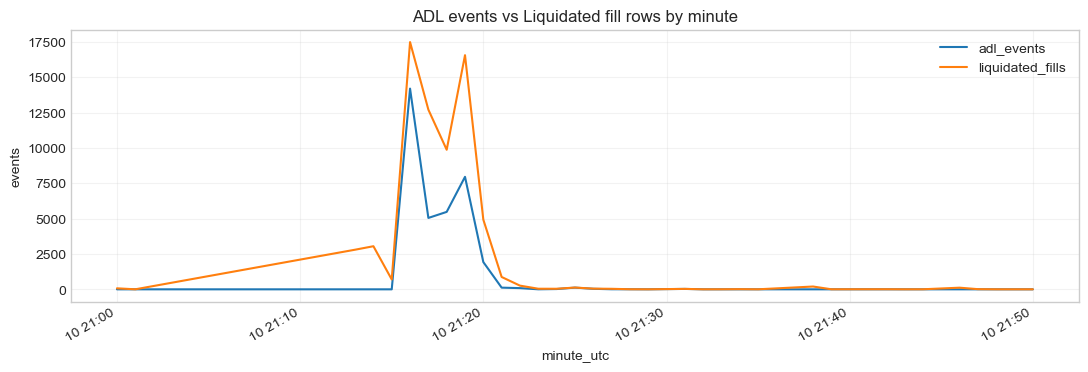

wrote notebooks/hyperliquid_20251010_21/question_outputs/q1_adl_vs_liquidation/q1_adl_vs_liquidation_minute_notional.png


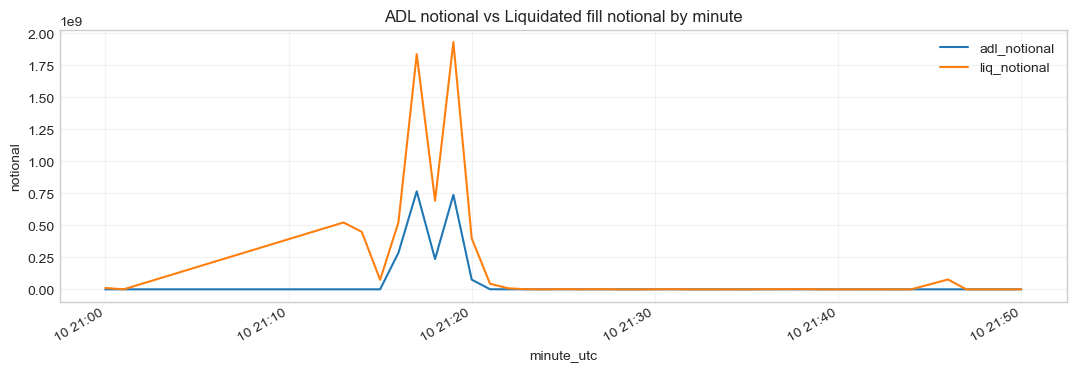

,cluster_1000ms,events,start,end,duration_ms,coins,notional
0,1,11279,2025-10-10 21:16:04.831000+00:00,2025-10-10 21:16:04.831000+00:00,0,44,1.85534e+08
1,2,2915,2025-10-10 21:16:56.356000+00:00,2025-10-10 21:16:56.356000+00:00,0,41,1.00013e+08
2,3,2468,2025-10-10 21:17:06.037000+00:00,2025-10-10 21:17:06.037000+00:00,0,4,3.86612e+08
3,14,2248,2025-10-10 21:18:44.652000+00:00,2025-10-10 21:18:44.652000+00:00,0,98,5.84755e+07
4,9,2226,2025-10-10 21:18:23.989000+00:00,2025-10-10 21:18:23.989000+00:00,0,72,1.4891e+08
5,23,1664,2025-10-10 21:19:25.321000+00:00,2025-10-10 21:19:25.321000+00:00,0,107,1.39789e+08
6,4,1179,2025-10-10 21:17:14.132000+00:00,2025-10-10 21:17:14.132000+00:00,0,56,7.44283e+07
7,21,1087,2025-10-10 21:19:18.209000+00:00,2025-10-10 21:19:18.209000+00:00,0,92,2.42281e+07
8,7,1035,2025-10-10 21:17:47.450000+00:00,2025-10-10 21:17:47.450000+00:00,0,4,2.96051e+08
9,33,954,2025-10-10 21:20:04.816000+00:00,2025-10-10 21:20:04.816000+00:00,0,110,2.85261e+07


wrote notebooks/hyperliquid_20251010_21/question_outputs/q1_adl_vs_liquidation/q1_adl_clusters_1000ms_top.csv
wrote notebooks/hyperliquid_20251010_21/question_outputs/q1_adl_vs_liquidation/q1_adl_interarrival_gap_scatter.png


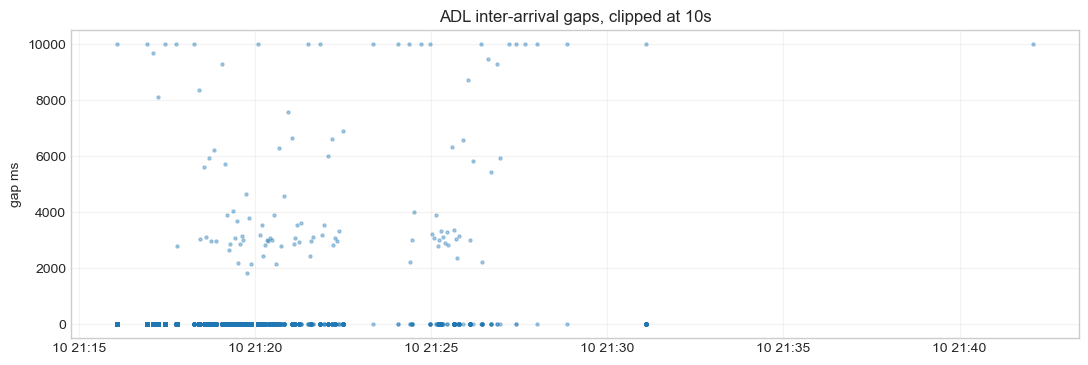

In [12]:
coin_dist = adl.groupby('coin').agg(adl_events=('adl_id','size'), adl_notional=('notional','sum'), addresses=('address','nunique'), liquidated_users=('effectiveLiquidatedUser','nunique')).sort_values('adl_notional', ascending=False)
coin_dist['event_share'] = coin_dist['adl_events'] / coin_dist['adl_events'].sum()
coin_dist['notional_share'] = coin_dist['adl_notional'] / coin_dist['adl_notional'].sum()
write_table(coin_dist.reset_index(), 'q1_adl_coin_distribution.csv')

adl_minute = adl.groupby('minute_utc').agg(adl_events=('adl_id','size'), adl_notional=('notional','sum'), coins=('coin','nunique'), addresses=('address','nunique'), liquidated_users=('effectiveLiquidatedUser','nunique')).sort_index()
liq_minute = liquidated_fills.groupby('minute_utc').agg(liquidated_fills=('coin','size'), liq_notional=('notional','sum'), liq_coins=('coin','nunique')).sort_index()
series = adl_minute.join(liq_minute, how='outer').fillna(0)
write_table(series.reset_index(), 'q1_adl_liquidation_minute_timeseries.csv')
plot_ts(series, ['adl_events','liquidated_fills'], 'ADL events vs Liquidated fill rows by minute', 'events', 'q1_adl_vs_liquidation_minute_counts.png')
plot_ts(series, ['adl_notional','liq_notional'], 'ADL notional vs Liquidated fill notional by minute', 'notional', 'q1_adl_vs_liquidation_minute_notional.png')

adl_sorted = adl.sort_values('time').copy()
adl_sorted['gap_ms'] = adl_sorted['time'].astype(float).diff().fillna(np.inf)
for threshold in [100, 1000, 5000]:
    adl_sorted[f'cluster_{threshold}ms'] = (adl_sorted['gap_ms'] > threshold).cumsum()
clusters = adl_sorted.groupby('cluster_1000ms').agg(
    events=('adl_id','size'),
    start=('time_utc','min'),
    end=('time_utc','max'),
    duration_ms=('time', lambda s: int(s.max() - s.min())),
    coins=('coin','nunique'),
    notional=('notional','sum'),
).sort_values(['events','notional'], ascending=False)
write_table(clusters.head(100).reset_index(), 'q1_adl_clusters_1000ms_top.csv')
fig, ax = plt.subplots(figsize=(13,4))
ax.scatter(adl_sorted['time_utc'], adl_sorted['gap_ms'].clip(upper=10000), s=5, alpha=.35)
ax.set_title('ADL inter-arrival gaps, clipped at 10s')
ax.set_ylabel('gap ms')
ax.grid(True, alpha=.25)
save_fig(fig, 'q1_adl_interarrival_gap_scatter.png')
plt.show()

## ADL and Market State: L2 and Asset Context Join

,minute_utc,coin,adl_events,adl_notional,snapshots,mean_mid,mean_spread_bps,median_depth20_notional,mean_imbalance20,funding,open_interest,basis_mark_oracle_bps,impact_spread_bps
271,2025-10-10 21:19:00+00:00,BTC,1020,3.26007e+08,110,"105,646",26.9646,4.17525e+06,0.341323,-0.000283913,"31,876.1",-61.9585,1.37837
80,2025-10-10 21:17:00+00:00,ETH,464,2.6225e+08,108,"3,516.62",19.8765,2.96868e+06,-0.0737362,-0.00022135,"738,963",-49.4444,52.959
73,2025-10-10 21:17:00+00:00,BTC,1043,2.5049e+08,108,"107,015",25.7949,3.2398e+06,-0.0248903,-0.00011688,"37,010.6",-35.9952,126.091
286,2025-10-10 21:19:00+00:00,ETH,1028,1.95758e+08,110,"3,382.63",74.0453,2.25307e+06,-0.457761,-0.000420841,"565,886",-125.74,266.93
107,2025-10-10 21:17:00+00:00,SOL,1812,1.66021e+08,108,167.863,79.026,1.97474e+06,-0.463308,-0.000218803,5.90358e+06,-160.67,430.7
20,2025-10-10 21:16:00+00:00,HYPE,5441,1.3699e+08,107,34.4376,70.3153,"241,923",-0.0678603,-0.0011211,2.6751e+07,-666.335,0.276243
348,2025-10-10 21:19:00+00:00,SOL,1196,1.10161e+08,110,150.299,141.357,1.21586e+06,-0.639894,-0.000822528,3.88158e+06,-438.178,314.22
413,2025-10-10 21:20:00+00:00,BTC,372,4.43809e+07,103,"104,020",10.7924,9.21652e+07,0.702424,-0.000295473,"24,421.7",-37.6525,0.0940734
167,2025-10-10 21:18:00+00:00,HYPE,447,3.55981e+07,108,33.9797,128.705,"391,406",-0.287222,-0.00182775,1.88267e+07,-584.471,137.534
140,2025-10-10 21:18:00+00:00,AVAX,202,3.03485e+07,108,17.3364,201.161,"319,889",-0.706557,-0.000183066,4.21524e+06,-100.586,787.674


wrote notebooks/hyperliquid_20251010_21/question_outputs/q1_adl_vs_liquidation/q1_adl_market_state_top_windows.csv


,has_adl,rows,mean_spread_bps,p95_spread_bps,median_depth20,mean_abs_imbalance,median_open_interest,p95_impact_spread_bps
0,False,12685,193.183,807.905,"44,825.5",0.221722,3.87102e+06,"13,473.1"
1,True,552,604.738,"1,610.63","60,399.4",0.282676,9.80672e+06,"15,105.8"


wrote notebooks/hyperliquid_20251010_21/question_outputs/q1_adl_vs_liquidation/q1_market_state_adl_vs_non_adl.csv
wrote notebooks/hyperliquid_20251010_21/question_outputs/q1_adl_vs_liquidation/q1_adl_coin_minute_heatmap.png


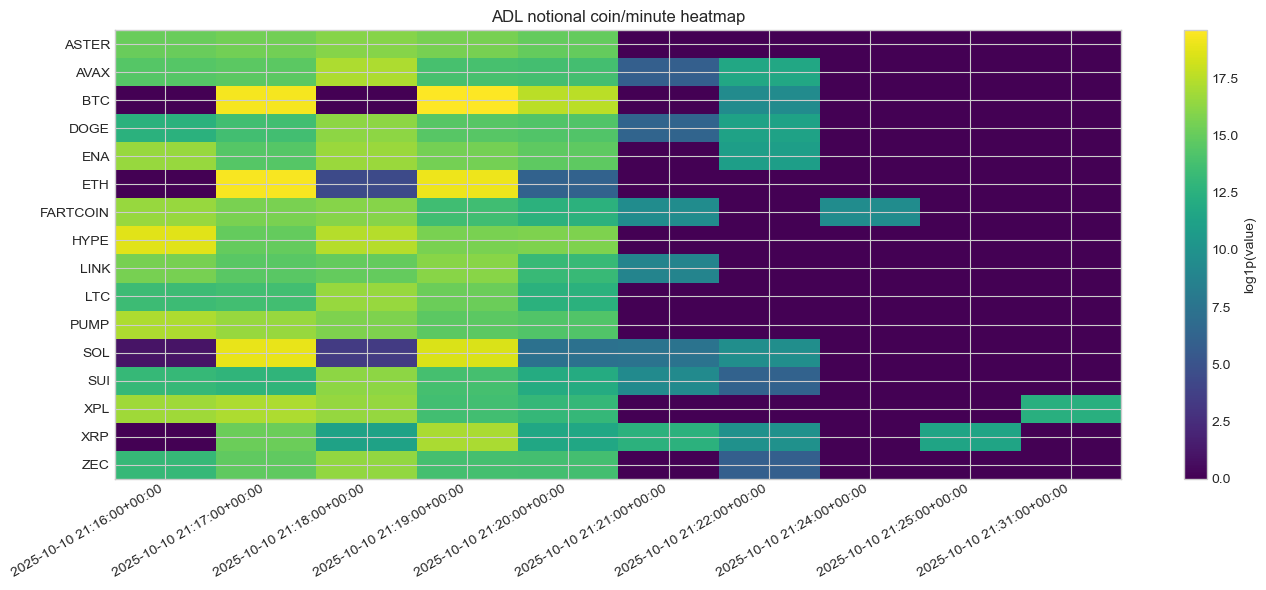

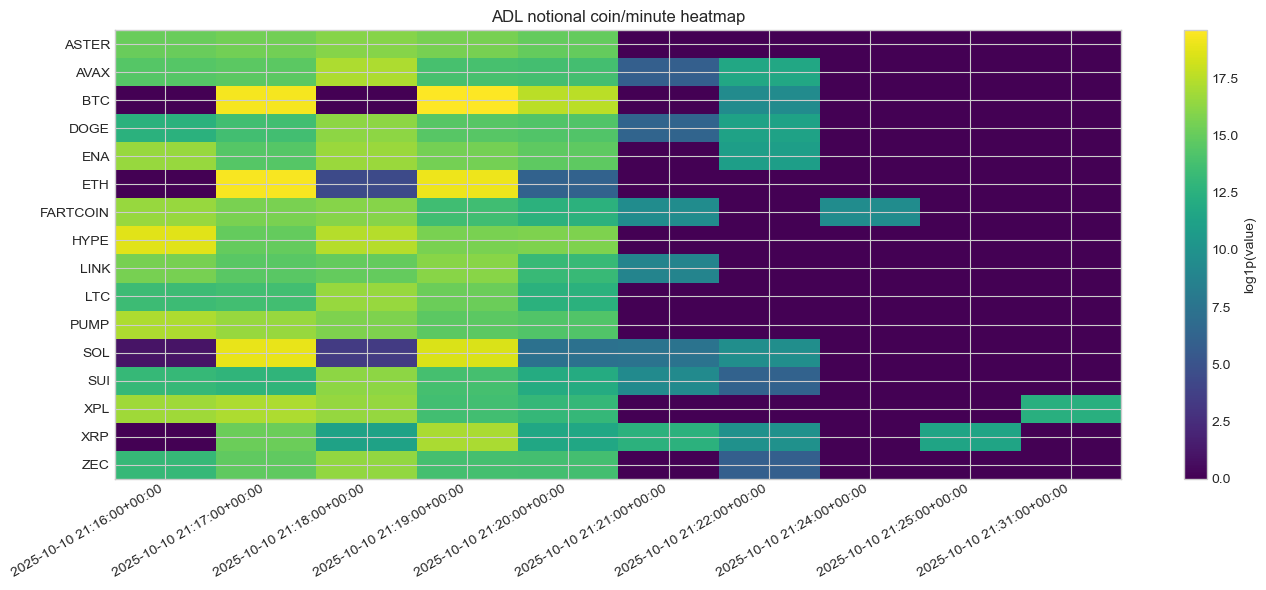

In [13]:
adl_coin_min = adl.groupby(['minute_utc','coin']).agg(adl_events=('adl_id','size'), adl_notional=('notional','sum')).reset_index()
market = l2_min.merge(asset_hour[['minute_utc','coin','funding','open_interest','basis_mark_oracle_bps','impact_spread_bps']], on=['minute_utc','coin'], how='left')
adl_market = adl_coin_min.merge(market, on=['minute_utc','coin'], how='left')
write_table(adl_market.sort_values('adl_notional', ascending=False).head(200), 'q1_adl_market_state_top_windows.csv')

market['has_adl'] = market.set_index(['minute_utc','coin']).index.isin(adl_coin_min.set_index(['minute_utc','coin']).index)
state_compare = market.groupby('has_adl').agg(
    rows=('coin','size'),
    mean_spread_bps=('mean_spread_bps','mean'),
    p95_spread_bps=('mean_spread_bps', lambda s: s.quantile(.95)),
    median_depth20=('median_depth20_notional','median'),
    mean_abs_imbalance=('mean_imbalance20', lambda s: s.abs().mean()),
    median_open_interest=('open_interest','median'),
    p95_impact_spread_bps=('impact_spread_bps', lambda s: s.quantile(.95)),
).reset_index()
write_table(state_compare, 'q1_market_state_adl_vs_non_adl.csv')

top_coins = coin_dist.head(16).index.tolist()
pivot = adl[adl['coin'].isin(top_coins)].pivot_table(index='minute_utc', columns='coin', values='notional', aggfunc='sum').fillna(0).sort_index()
log_heatmap(pivot, 'ADL notional coin/minute heatmap', 'q1_adl_coin_minute_heatmap.png')

## Representative Case Detail Tables

In [14]:
case_cols = ['adl_id','blockNumber','time_utc','coin','px','sz','notional','address','effectiveLiquidatedUser','adlSide','liquidatedSide','adlFillIndex','liquidatedFillIndex','liquidationMethod','liquidationMarkPx','liquidationMarkDistanceBps','hash','oid','tid']
cases = adl.sort_values('notional', ascending=False)[case_cols].head(100)
write_table(cases, 'q1_typical_adl_cases_top_notional.csv')

,adl_id,blockNumber,time_utc,coin,px,sz,notional,address,effectiveLiquidatedUser,adlSide,liquidatedSide,adlFillIndex,liquidatedFillIndex,liquidationMethod,liquidationMarkPx,liquidationMarkDistanceBps,hash,oid,tid
18267,18267,758801668,2025-10-10 21:17:47.450000+00:00,BTC,"107,228","1,803.36",1.9337e+08,0xb317d2bc2d3d2df5fa441b5bae0ab9d8b07283ae,0xb0a55f13d22f66e6d495ac98113841b2326e9540,B,A,2120,2121,backstop,"106,348",82.7472,0xf6708d1c772bd97bf7ea042d3a6504010600a502122e...,194019986854,310773606135761
15440,15440,758801258,2025-10-10 21:17:06.037000+00:00,ETH,"3,561.2","48,909.5",1.74176e+08,0x2ea18c23f72a4b6172c55b411823cdc5335923f4,0xb0a55f13d22f66e6d495ac98113841b2326e9540,B,A,8410,8411,backstop,"3,538.4",64.4359,0x784fd33f92195e9079c9042d3a636a010f00eb252d1c...,194019304535,133066960337337
27288,27288,758802725,2025-10-10 21:19:22.251000+00:00,BTC,"107,350",711.656,7.63963e+07,0xb317d2bc2d3d2df5fa441b5bae0ab9d8b07283ae,0xb0a55f13d22f66e6d495ac98113841b2326e9540,B,A,2366,2367,backstop,"106,216",106.764,0xec2dce1b539d7e70eda7042d3a6925000068e600ee90...,194021460572,82384347296095
27967,27967,758802763,2025-10-10 21:19:25.321000+00:00,BTC,"106,216",664.697,7.06015e+07,0x8decc13b6e83873a78126e99036f9442019fd0b5,0xb0a55f13d22f66e6d495ac98113841b2326e9540,B,A,2434,2435,backstop,"105,809",38.4655,0x56270b21b0e492a857a0042d3a694b015f0023074be7...,194021509311,813022930379745
15912,15912,758801258,2025-10-10 21:17:06.037000+00:00,SOL,173.05,"269,598",4.66539e+07,0x35d1151ef1aab579cbb3109e69fa82f94ff5acb1,0xb0a55f13d22f66e6d495ac98113841b2326e9540,B,A,9354,9355,backstop,172.59,26.6528,0x784fd33f92195e9079c9042d3a636a010f00eb252d1c...,194019305007,67895181708484
27356,27356,758802725,2025-10-10 21:19:22.251000+00:00,ETH,"3,433.6","12,032.8",4.13159e+07,0x2ea18c23f72a4b6172c55b411823cdc5335923f4,0xb0a55f13d22f66e6d495ac98113841b2326e9540,B,A,2502,2503,backstop,"3,432.9",2.03909,0xec2dce1b539d7e70eda7042d3a6925000068e600ee90...,194021460640,520840004323364
27342,27342,758802725,2025-10-10 21:19:22.251000+00:00,ETH,"3,433.6","12,000",4.12032e+07,0x8decc13b6e83873a78126e99036f9442019fd0b5,0xb0a55f13d22f66e6d495ac98113841b2326e9540,B,A,2474,2475,backstop,"3,432.9",2.03909,0xec2dce1b539d7e70eda7042d3a6925000068e600ee90...,194021460626,370411646667993
18430,18430,758801668,2025-10-10 21:17:47.450000+00:00,ETH,"3,545.2","10,796.3",3.82749e+07,0x091159a8106b077c13e89bc09701117e8b5f129a,0xb0a55f13d22f66e6d495ac98113841b2326e9540,B,A,2446,2447,backstop,"3,541.3",11.0129,0xf6708d1c772bd97bf7ea042d3a6504010600a502122e...,194019987017,559083689972356
24859,24859,758802565,2025-10-10 21:19:08.820000+00:00,BTC,"108,202",280.093,3.03066e+07,0x960bb18454cd67b5a3edb4fa802b7c0b5b10e2ee,0xb0a55f13d22f66e6d495ac98113841b2326e9540,B,A,2726,2727,backstop,"107,765",40.5512,0xb94a94f415be9943bac4042d3a688502019200d9b0b1...,194021235362,368837530711155
25404,25404,758802565,2025-10-10 21:19:08.820000+00:00,SOL,160.58,"183,822",2.95181e+07,0x880ac484a1743862989a441d6d867238c7aa311c,0xb0a55f13d22f66e6d495ac98113841b2326e9540,B,A,3816,3817,backstop,159.99,36.8773,0xb94a94f415be9943bac4042d3a688502019200d9b0b1...,194021235907,636413320550188


wrote notebooks/hyperliquid_20251010_21/question_outputs/q1_adl_vs_liquidation/q1_typical_adl_cases_top_notional.csv


,adl_id,blockNumber,time_utc,coin,px,sz,notional,address,effectiveLiquidatedUser,adlSide,liquidatedSide,adlFillIndex,liquidatedFillIndex,liquidationMethod,liquidationMarkPx,liquidationMarkDistanceBps,hash,oid,tid
18267,18267,758801668,2025-10-10 21:17:47.450000+00:00,BTC,"107,228","1,803.36",1.9337e+08,0xb317d2bc2d3d2df5fa441b5bae0ab9d8b07283ae,0xb0a55f13d22f66e6d495ac98113841b2326e9540,B,A,2120,2121,backstop,"106,348",82.7472,0xf6708d1c772bd97bf7ea042d3a6504010600a502122e...,194019986854,310773606135761
15440,15440,758801258,2025-10-10 21:17:06.037000+00:00,ETH,"3,561.2","48,909.5",1.74176e+08,0x2ea18c23f72a4b6172c55b411823cdc5335923f4,0xb0a55f13d22f66e6d495ac98113841b2326e9540,B,A,8410,8411,backstop,"3,538.4",64.4359,0x784fd33f92195e9079c9042d3a636a010f00eb252d1c...,194019304535,133066960337337
27288,27288,758802725,2025-10-10 21:19:22.251000+00:00,BTC,"107,350",711.656,7.63963e+07,0xb317d2bc2d3d2df5fa441b5bae0ab9d8b07283ae,0xb0a55f13d22f66e6d495ac98113841b2326e9540,B,A,2366,2367,backstop,"106,216",106.764,0xec2dce1b539d7e70eda7042d3a6925000068e600ee90...,194021460572,82384347296095
27967,27967,758802763,2025-10-10 21:19:25.321000+00:00,BTC,"106,216",664.697,7.06015e+07,0x8decc13b6e83873a78126e99036f9442019fd0b5,0xb0a55f13d22f66e6d495ac98113841b2326e9540,B,A,2434,2435,backstop,"105,809",38.4655,0x56270b21b0e492a857a0042d3a694b015f0023074be7...,194021509311,813022930379745
15912,15912,758801258,2025-10-10 21:17:06.037000+00:00,SOL,173.05,"269,598",4.66539e+07,0x35d1151ef1aab579cbb3109e69fa82f94ff5acb1,0xb0a55f13d22f66e6d495ac98113841b2326e9540,B,A,9354,9355,backstop,172.59,26.6528,0x784fd33f92195e9079c9042d3a636a010f00eb252d1c...,194019305007,67895181708484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26666,26666,758802675,2025-10-10 21:19:18.209000+00:00,TAO,206.39,"12,500",2.57988e+06,0xd47587702a91731dc1089b5db0932cf820151a91,0x2e3d94f0562703b25c83308a05046ddaf9a8dd14,B,A,3548,3549,backstop,191.17,796.15,0x43bc1c33f1a05e524535042d3a68f301030034198ca3...,194021395616,235588583499500
11321,11321,758801157,2025-10-10 21:16:56.356000+00:00,LINK,16.649,"153,576",2.55689e+06,0xd4c1f7e8d876c4749228d515473d36f919583d1d,0x2e3d94f0562703b25c83308a05046ddaf9a8dd14,B,A,5994,5995,backstop,16.376,166.707,0x4be48dd0dfaa8b414d5e042d3a6305010900a5b67aad...,194019136048,702534847548952
19059,19059,758801668,2025-10-10 21:17:47.450000+00:00,SOL,168.21,"15,124.2",2.54404e+06,0x27c9fa86c91b84ddfa15de58c482ff662498d65d,0xb0a55f13d22f66e6d495ac98113841b2326e9540,B,A,3704,3705,backstop,168.14,4.1632,0xf6708d1c772bd97bf7ea042d3a6504010600a502122e...,194019987646,361300172336455
21305,21305,758802055,2025-10-10 21:18:23.989000+00:00,ASTER,1.077,2.28512e+06,2.46108e+06,0x4f7634c03ec4e87e14725c84913ade523c6fad5a,0x2e3d94f0562703b25c83308a05046ddaf9a8dd14,B,A,6504,6505,backstop,1.0633,128.844,0x25c553f2de4cff14273f042d3a66870179006bd87940...,194020556210,622464154619635


## Mechanism Checks, Unverifiable Areas, and Final Conclusion

In [15]:
ev = evidence([
    {'claim':'ADL rows have direct paired liquidation fill information in cleaned adl_events.', 'evidence_level':'Confirmed', 'evidence':f"paired fillIndex rate={paired_quality.loc[0,'paired_fillIndex_rate']:.4f}; effective liquidated user rate={paired_quality.loc[0,'effective_liquidated_user_rate']:.4f}", 'limitation':'This confirms fill-level pairing in cleaned data, not protocol causality beyond available fields.'},
    {'claim':'Most ADL rows match liquidation fills under exact trade-key / tight time windows.', 'evidence_level':'Confirmed' if match_summary['match_rate'].max() > .95 else 'Likely', 'evidence':match_summary.to_dict('records'), 'limitation':'If a liquidation is split across multiple fills, event-level causality requires aggregation rules.'},
    {'claim':'One liquidation event can correspond to multiple ADL fills.', 'evidence_level':'Confirmed' if (liq_to_adl['adl_fills'] > 1).any() else 'Rejected', 'evidence':f"liq keys with >1 ADL fills={(liq_to_adl['adl_fills'] > 1).sum()}", 'limitation':'The chosen liquidation key is fill/trade-derived; ledger event id may group differently.'},
    {'claim':'One ADL aggregate can involve multiple accounts, fills, or coins.', 'evidence_level':'Confirmed' if ((trade_agg['adl_fills']>1) | (trade_agg['adl_addresses']>1) | (trade_agg['coins']>1)).any() else 'Rejected', 'evidence':multiplicity.to_dict('records'), 'limitation':'Aggregation key uses block/time/hash/oid/tid.'},
    {'claim':'ADL happens in bursts/clusters rather than uniformly.', 'evidence_level':'Likely' if clusters['events'].max() > 5 else 'Inconclusive', 'evidence':f"max 1000ms cluster events={clusters['events'].max()}, top cluster notional={clusters['notional'].max():.6g}", 'limitation':'One-hour sample only; burst threshold is analytical, not protocol-defined.'},
    {'claim':'ADL is associated with stressed market state.', 'evidence_level':'Likely' if len(state_compare)==2 else 'Inconclusive', 'evidence':'See q1_market_state_adl_vs_non_adl.csv for spread/depth/imbalance comparison.', 'limitation':'Association is not causal; L2/asset_ctxs are minute-level approximations.'},
])
print('Final conclusion: ADL is strongly tied to liquidation fills in this cleaned dataset, but protocol-level causality and all split/grouping semantics require care. The notebook records exact, window, and aggregate matching separately.')

,claim,evidence_level,evidence,limitation
0,ADL rows have direct paired liquidation fill i...,Confirmed,paired fillIndex rate=1.0000; effective liquid...,This confirms fill-level pairing in cleaned da...
1,Most ADL rows match liquidation fills under ex...,Confirmed,"[{'window_ms': 0, 'adl_events': 35022, 'matche...",If a liquidation is split across multiple fill...
2,One liquidation event can correspond to multip...,Rejected,liq keys with >1 ADL fills=0,The chosen liquidation key is fill/trade-deriv...
3,One ADL aggregate can involve multiple account...,Rejected,"[{'unique_liq_keys': 35022, 'liq_keys_with_mul...",Aggregation key uses block/time/hash/oid/tid.
4,ADL happens in bursts/clusters rather than uni...,Likely,"max 1000ms cluster events=11279, top cluster n...",One-hour sample only; burst threshold is analy...
5,ADL is associated with stressed market state.,Likely,See q1_market_state_adl_vs_non_adl.csv for spr...,Association is not causal; L2/asset_ctxs are m...


wrote notebooks/hyperliquid_20251010_21/question_outputs/q1_adl_vs_liquidation/evidence_assessment.csv
Final conclusion: ADL is strongly tied to liquidation fills in this cleaned dataset, but protocol-level causality and all split/grouping semantics require care. The notebook records exact, window, and aggregate matching separately.
